In [ ]:
import matplotlib.pyplot as plt
import seaborn as sb

import numpy as np
import pandas as pd
from itertools import product
import random

from sklearn.neighbors import NearestNeighbors
from sklearn.tree import DecisionTreeClassifier
import sklearn as skl
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold,validation_curve,learning_curve,train_test_split,cross_val_score
from sklearn.metrics import (confusion_matrix,precision_score,recall_score,f1_score,accuracy_score,roc_curve,auc,precision_recall_curve,auc)

import seaborn as sns
from xgboost import XGBClassifier
'''
Abrir datods
'''
url = "https://storage.googleapis.com/jvelare-public/bq-results-20260211-093843-1770799837095"

df__nuevos_clientes = pd.read_csv('nuevos_clientes.csv')
df_costes = pd.read_csv('Costes.csv')
df_clientes=pd.read_csv(url)


'''
- Cambiar los datos para mejores Aplicaciones
- Crear Nuestra nueva variable Y que nos dice si cliente es Churn o no Churn
- Data labelling: creamos nuestra variable Y que es nuestro churn solo dependiendo de los dias de Sales por la ID del comprador {Siend nuestro}

'''
def analysis_data(clientes,costes,ploting=False):

    '''
    Dataset Descriptions and analysis
    - Info of the columns and there description
    - Total clients 58.049 from  2018 to 2023
    - Cambiar los datos para mejores Aplicaciones
    - Ver y plotear datos importantes que tengamos interes economico. Como por ejemplo las revisiones
    99.97% clientes que compraron modelo H son leales (2906 clientes leales que compraron modelo H del total 2907. {5% clientes compran este modelo H en otras palabras muy pocos [niche mercato]})
    - Tambiar sacar las variables A, Y
     '''
    Columns=clientes.columns

    clientes["Sales_Date"]=pd.to_datetime(clientes["Sales_Date"])# Change it to datetime
 
    jovenes=clientes[(clientes["Edad"]<35)]# 14_808 clientes Jovenes (20 a 35 años edad) 25.51% (25.14%)

    adultos=clientes[(35<=clientes["Edad"]) & (clientes["Edad"]<60)]# 40_342 (35 a 60 años edad) clientes Adultos 69.50% (69.92%). Comercio centrado en Adultos

    jubilados=clientes[(60<=clientes["Edad"]) & (clientes["Edad"]<80)]# 2_899 (60 a 80 años edad)  clientes jubilados 4.99% (4.94%)
    M_jo_E=jovenes.groupby("Modelo")["Edad"].describe()
# Modelos B,I son los mas vendidos por jovenes con 4094.0, 3796.0 respectivamente. Quiere decir que 27%,25% de los clientes jovenes compran este modelo. 
# En otras palabras al menos un 52% de clientes jovenes solo compran del modelo B e I
# G es el menos vendido solo 7 clientes lo compraron y 
    M_ad_E=adultos.groupby("Modelo")["Edad"].describe()
# Modelos B,I son los mas vendidos por adultos con 11099.0, 10314.0 respectivamente. Porcentage bendids pasra adultos es 27.51% 25.57% espectivamente 
# Enotras palabras el 53.08% de clientes adultos solo compran del modelo B e I
# Menos vendido G con 17.0 clientes que lo compraron
    M_ju_E=jubilados.groupby("Modelo")["Edad"].describe()
# Modelos B,I son los mas vendidos por adultos con 800.0,793.0 respectivamente. QQuiere decir 27.60% 27.35

# En otras palabras el 54.95% de los jubilados compran de estos dos modelos
# Los menos vendidos son Modelo G y F con solo una venta de cliente a sus 60 y 69 respectivamente

    M_jo_churn=jovenes.groupby("Modelo")["Churn_400"].describe()
# Modelo I:  9944/10314 = 96.41% No churn
# Modelo B: 9951/11099= 89.66% No churn (no nos gusta muy bajo por ahora la mayoria de otros modelos son 90+)
# Modelo H: Todos son No churns 752 clientes qndomForestClassifier

# 88.97% de clientes de todos los clientes Jovenes son leales
    M_ad_churn=adultos.groupby("Modelo")["Churn_400"].describe()
# Modelo I:  3796/3612 = 95.12% No churn
# Modelo B: 9951/4094= 85.27% No churn (no nos gusta muy bajo por ahora la mayoria de otros modelos son 90+)
# Modelo H: 99.95% of 2003 clientrs que compraron este modelo y son leales (2002)
# 91.60% de clientes de todos los clientes adultos son leales

    M_ju_churn=jubilados.groupby("Modelo")["Churn_400"].describe()
# Modelo I:  777/793 = 97.98% No churn
# Modelo B: 788/800= 98.5% No churn 
# Modelo H: Todos son No churns 152 clientes que compraron este modelo y 
# 98.55% de todos los clientes Jubilados son leales
    
    M_jo_genero=jovenes.groupby("Modelo")["GENERO"].describe()
# Modelo I: 2767/3763 = 73% hombres 
# Modelo B: 2795/4055= 69% hombres
# 64.51% de todos los clientes Jovenes son hombres
#  
    M_ad_genero=adultos.groupby("Modelo")["GENERO"].describe()
# Modelo I: 7628/10244 = 74% hombres 
# Modelo B: 7566/10989= 69% hombres
# 64.51% de todos los clientes Jovenes son hombres

    M_ju_genero=jubilados.groupby("Modelo")["GENERO"].describe()
# Modelo I: 7628/10244 = 74% hombres 
# Modelo B: 7566/10989= 69% hombres
# 64.51% de todos los clientes Jovenes son hombres
    
    M_jo_marge=jovenes.groupby("Modelo")[["Margen_eur_bruto","Margen_eur"]].describe()

    M_ad_marge=adultos.groupby("Modelo")[["Margen_eur_bruto","Margen_eur"]].describe()

    M_ju_marge=jubilados.groupby("Modelo")[["Margen_eur_bruto","Margen_eur"]].describe()

    # salida=M_ju_marge.groupby("Churn_400")["Edad"].describe()

    """
    Data managing cleaning 
    """
    # Cleaning Full data
    clientes.dropna(axis=1,inplace=True)
# Seleccionar variables

    X = clientes.drop(['CODE','Sales_Date','FIN_GARANTIA','Churn_400','Customer_ID','Id_Producto','Revisiones','km_ultima_revision'], axis=1)
    y = clientes['Churn_400'].map({'N':0,'Y':1})
    # print(clientes['Churn_400'].head(10))
    # Convertir categóricas a numéricas
    X = pd.get_dummies(X, drop_first=True)

    return X,y,(Columns,M_ad_E,M_ju_E)
    # clientes.groupby("Modelo")["Edad"].describe()
    """
    Pero esa solo es existencia suficiente pero no necesaria.
    En otras palabras puede que alguien haya comprado proximo 
    al ultimo dia pero la differencia con el primer producto que compro es mayor a 40
    - Por ello tenemos que comprobar otra vez con las diferencias
    cus_date.count().max()
    cuantos dias maximo que son dos
    """



    # diff=max_day-nin_day
    # diff[diff>pd.Timedelta(days=40)]=1 # the rest of the Churns 1
    # max_day.combine(diff,lambda x,y:1 if (x==1 or y==1) else 0)
    # # cus_date.diff()[cus_date.diff()>pd.Timedelta(days=0)]
    # max_day[max_day!=1]=0
    # clientes_churn=clientes.merge(max_day.rename("Churn").reset_index().rename(columns={"index":"Customer_ID"}),on="Customer_ID",how='left')

    # clientes_churn[clientes['MOTIVO_VENTA']]

    # clientes_churn[clientes['SEGURO_BATERIA_LARGO_PLAZO']]
    
    # clientes_churn.drop("QUEJA")[clientes['QUEJA']] # isall null
    
    # clientes_churn[clientes['Origen']]
    
    # clientes_churn[clientes['EXTENSION_GARANTIA']]

    # clientes_churn[clientes['GENERO']]
    
    # clientes_churn[clientes['EN_GARANTIA']]
    
    # clientes_churn[clientes['EN_GARANTIA']]
    
    # clientes_churn[clientes['EN_GARANTIA']]
    
    # clientes_churn[clientes['EN_GARANTIA']]


    
        # return X,y,other




def decision_trees_analysis(X,Y,criterion, splitter, max_depth, min_samples_split, min_samples_leaf,test_size=0.20,random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, Y, test_size=test_size, random_state=random_state, stratify=Y
    )
    
    # Modelos
    tree_model = DecisionTreeClassifier(
        criterion=criterion, splitter=splitter, max_depth=max_depth,
        min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf
    )
    
    random_forest_model = RandomForestClassifier(
        criterion=criterion, max_depth=max_depth,
        min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf,
        n_estimators=100, random_state=random_state
    )
    
    xgboost_model = XGBClassifier(
        max_depth=max_depth, min_child_weight=min_samples_split,
        random_state=random_state
    )
    
    # Entrenar modelos
    tree_model.fit(X_train, y_train)
    random_forest_model.fit(X_train, y_train)
    xgboost_model.fit(X_train, y_train)
    
    models = {
        "DecisionTree": tree_model,
        "RandomForest": random_forest_model,
        "XGBoost": xgboost_model
    }
    
    return models, X_train, X_test, y_train, y_test
# svm_model=


    # return decision_tree
    pass

def Naive_bayes():
    pass

"""

"""
    # DecisionTreeClassifier(criterion, splitter, max_depth, min_samples_split, min_samples_leaf,l)

def Top_model():
    pass

def analysis_error(models,X_train,y_train,X_test,y_test,cv=5,f1_threshold=0.6):
    # range=20% Rechazar
    # 10% sobreajusta  tree,random_forest,xgboost
    """
    Test part to check error
    """
    results = {}

    for name, model in models.items():
        print(name)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None

        # Métricas
        cm = confusion_matrix(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        accuracy = accuracy_score(y_test, y_pred)

        # --- Visualización con Seaborn ---
        print(f"\n=== {name} ===")
        print(f"Accuracy: {accuracy:.3f}, F1: {f1:.3f}, ROC AUC: {roc_auc:.3f}, PR AUC: {pr_auc:.3f}")

        # Confusion Matrix
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
        plt.title(f"{name} - Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

        # ROC y PR
        if y_prob is not None:
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            roc_auc = auc(fpr, tpr)
            precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
            pr_auc = auc(recall_vals, precision_vals)
        
            plt.figure(figsize=(6,4))
            sns.lineplot(x=fpr, y=tpr, marker="o", label=f"ROC AUC = {roc_auc:.2f}", color="blue")
            sns.lineplot(x=[0,1], y=[0,1], linestyle="--", color="gray")
            plt.title(f"{name} - ROC Curve")
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.legend(loc="lower right")
            plt.show()

            # Precision-Recall Curve
            plt.figure(figsize=(6,4))
            sns.lineplot(x=recall_vals, y=precision_vals, marker="o", label=f"PR AUC = {pr_auc:.2f}", color="green")
            plt.title(f"{name} - Precision-Recall Curve")
            plt.xlabel("Recall")
            plt.ylabel("Precision")
            plt.legend(loc="lower left")
            plt.show()
        else:
            fpr, tpr, roc_auc = None, None, None
            precision_vals, recall_vals, pr_auc = None, None, None

        # Cross-validation StratifiedKFold
        skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
        cv_scores = cross_val_score(model, X_train, y_train, cv=skf,)
        cv_scores_f1 = cross_val_score(model, X_train, y_train, cv=skf,scoring="f1")
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
        cv_f1 = cv_scores_f1.mean()
        cv_std_f1 = cv_scores_f1.std()

        results[name] = {
            "confusion_matrix": cm,
            
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "accuracy": accuracy,
            
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
            
            "cv_mean_acc": cv_mean,
            "cv_std_acc": cv_std,
            
            "cv_mean_f1": cv_f1,
            "cv_std_f1": cv_std_f1,

            "deviation_f1" : abs(cv_f1 - f1) / f1,
            "deviation_acc" : abs(cv_mean - accuracy) / accuracy
        
        }

    deviation_f1 = abs(cv_f1 - f1) / f1
    deviation_acc = abs(cv_mean - accuracy) / accuracy
    
    candidate= {}
    
    for name, metrics in results.items():
        if f1_threshold<=metrics["f1"]<=0.9 \
           and metrics["roc_auc"] is not None and 0.7 <= metrics["roc_auc"] <= 0.8 \
           and metrics["pr_auc"] is not None and 0.7 <= metrics["pr_auc"] <= 0.8 \
           and metrics["deviation_f1"]<=0.2 \
           or  metrics["deviation_acc"]<=0.2:
            candidate[name] = metrics["deviation_acc"]
                
    return results, min(candidate, key=candidate.get)# results = {name_model:results} , min(candidate)=
    # return results


# 91.22637772% No Churn: 
# 8.773622285% Si churn: 
# Si cojemos para test un 80%--> 90% No churn y 10% Si churn. Overfitting a No churn?
# Si me dejas. Sabiendo que me dejas mi empresa que haria. Tratrte mal o mejor (cambiarles a leales){Convertirse en leales}? Solo tratarte bien si no me dejas (hacer que los que ya me garantizan lealtad se vuelvan mas leales){Que mis leales sigan siedo leales}?
# Con estos datos puedo deducir que la empresa se dedica a dar cuidado muy buenos a los leales
# Asi que es mejor crear lealtad maxima a los que vamos a saber que van a ser leales
#  Para ello queremos asegurar detectar a los infieles para asi poder saber donde gastar dinero para lealtad.
# Pude que un porcentaje queramos convertirles a leales

if __name__=="__main__":
    
    # Decision Tree Analysis
    
    param_grid = {
        'criterion': ['gini', 'entropy', 'log_loss'],
        'splitter': ['best', 'random'],
        'max_depth': [3, 5, 10],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 5,6]

    }

    results = []
    salida= {}
    for params in product(*param_grid.values()):
        criterion, splitter, max_depth, min_samples_split, min_samples_leaf = params
        print(params)
        X,Y,parmetros=analysis_data(df_clientes,df_costes)

        models, X_train, X_test, y_train, y_test=decision_trees_analysis(X,Y,criterion, splitter, max_depth, min_samples_split, min_samples_leaf)
        
        result,best=analysis_error(models,X_train,y_train,X_test,y_test,cv=5)
        # errors son los errores de cada modelo
        results.append(result)
        salida[best]=params
    
        # salida[random_forest]=("gini",2,3,4)

    # for i in salida:
    #     data=Top_model(i)
    #     print(data)

# analysis_data(df_clientes,df_costes)[0]


In [ ]:
# df_sales_month=df_clientes.set_index('Sales_Date').resample('M')["PVP"].sum()
# df_sales_week=df_clientes.set_index('Sales_Date').resample('W').size()
# df_sales_year=df_clientes.set_index('Sales_Date').resample('Y').size()
# df_sales_days=df_clientes.set_index('Sales_Date').resample('D').size()
# dfs_sales.groupby("Sales_Date")["PVP"].count()[:366]
# dfs_sales.groupby("Sales_Date")["PVP"].count()[365:365+366]
# dfs_sales.groupby("Sales_Date")["PVP"].count()[365+365:365+365+317]
# dfs_sales.groupby("Sales_Date")["PVP"].count()[365+365+316:365+365+317+360]
# datos=[dfs_sales.groupby("Sales_Date")["PVP"].count()[i*365:i*365+365] for i in range(5)]
# df_sales_month.plot(kind="bar")
# df_sales_month.plot(kind="bar")

# df_sales_week.plot(kind="bar")
# df_sales_year.plot(kind="bar")
# df_sales_days.plot()

In [ ]:

df_clientes["MOTIVO_VENTA"]=="Particular"

In [ ]:
# df_clientes["Motivo_venta_Particular"]=df_clientes["MOTIVO_VENTA"]=="Particular"

In [ ]:
dl=df_clientes.drop(["CODE","Customer_ID"],axis=1)
dl.info()
# df_clientes

In [ ]:
# dtypes: float64(3), int64(13), object(24)


In [ ]:
df_clientes.groupby("Modelo")["GENERO"].describe()

In [ ]:
# sal=df_clientes[df_clientes["Modelo"]=='K']["GENERO"]

# Modelo A
# 7264
# 98 NAN 
# Female 3_803
# Male 3_363
# Modelo A:{NAN: 1.07% Female: 52.35% , Male: 46.30%}

# Modelo B
# 15_993
# NAN 156
# Female 4934
# Male 10903
# Modelo B:{NAN: 0.9754% Female: 30.85% , Male: 68.17%}

# Modelo C
# 4_328
# NAN 81
# Female 1322
# Male 2925
# Modelo C:{NAN: 1.87% Female: 30.55% , Male: 67.58%}

# Modelo D
# 9165
# NAN 190
# Female 2041
# Male 6934
# Modelo D:{NAN: 2.07% Female: 22.27% , Male: 75.57%}

# Modelo E
# 703*
# NAN 13*
# Female 206*
# Male 484*
# Modelo E:{NAN: 1.25% Female: 29.30% , Male: 68.85%}

# Modelo F
# 29**
# NAN 1**(male)
# Female 6**
# Male 22**
# Modelo F:{NAN: 3.45% Female: 20.69% , Male: 75.86%}

# Modelo G
# 25***
# NAN 4***(1,3)
# Female 6***
# Male 15***
# Modelo G:{NAN: 16% Female: 24% , Male: 60%}

# Modelo H
# 2907** **
# NAN 8** **(3,5)
# Female 1047** **
# Male 1852** **
# Modelo H:{NAN: 0.28% Female: 36.02% , Male: 63.71%}

# Modelo I
# 14903*****
# NAN 107****(28,79)
# Female 3803*****
# Male 10993*****
# Modelo I:{NAN: 0.72% Female: 25.52% , Male: 73.76%}

# Modelo J
# 2617******
# NAN 181******(44,137)
# Female 649******
# Male 1787******
# Modelo J:{NAN: 2.07% Female: 22.27% , Male: 75.57%}

# Modelo K
# 115*******
# NAN 10*******(3,7)
# Female 25*******
# Male 80*******
# Modelo K:{NAN: 8.70% Female: 21.74% , Male: 69.57%}

# sal[sal=='F'].shape
url = "https://storage.googleapis.com/jvelare-public/bq-results-20260211-093843-1770799837095"

df_clientes=pd.read_csv(url)
# df_clientes.info()
df_clientes.GENERO

In [ ]:
import pandas as pd
import itertools
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_recall_curve, auc, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer

# --- Preparar datos ---
def preparar_datos(df):
    df = df.drop(columns=["CODE","DAYS_LAST_SERVICE", "STATUS_SOCIAL",'Revisiones'], errors="ignore")#, "Customer_ID" Not relevant
    
    df["QUEJA"] = df["QUEJA"].fillna("N")
    

    genero_mode_per_modelo = df.groupby("Modelo")["GENERO"].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
    
    # Apply fillna per row
    df["GENERO"] = df.apply(
        lambda row: genero_mode_per_modelo[row["Modelo"]] if pd.isna(row["GENERO"]) else row["GENERO"],
        axis=1
    )
    
    y = df["Churn_400"]
    X = df.drop(columns=["Churn_400"])

    # convertir fechas a numéricas
    for col in X.select_dtypes(include="datetime64[ns]").columns:
        
        X = X.drop(columns=[col])

    # encoding categóricas
    X = pd.get_dummies(X, drop_first=True)



    return X, y

# --- Evaluar un modelo usando StratifiedKFold ---
def evaluar_modelo(modelo, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    f1_list = []
    pr_auc_list = []
    roc_auc_list = []
    diff_error_list = []
    f1 = f1_score(y_test, pred)
    
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_test)
        prob = modelo.predict_proba(X_test)[:,1]

        
        precision, recall, _ = precision_recall_curve(y_test, prob)
        pr_auc = auc(recall, precision)
        roc_auc = roc_auc_score(y_test, prob)

        error_test = 1 - f1
        cv_error = 1 - f1  # usando f1 de este fold como referencia
        diff_error = abs(cv_error - error_test)

        f1_list.append(f1)
        pr_auc_list.append(pr_auc)
        roc_auc_list.append(roc_auc)
        diff_error_list.append(diff_error)

    # Promedio de folds
    return {
        "modelo": modelo,
        "f1": np.mean(f1_list),
        "pr_auc": np.mean(pr_auc_list),
        "roc_auc": np.mean(roc_auc_list),
        "diff_error": np.mean(diff_error_list)
    }

def entrenar_modelos_comb(params, X, y):
    criterion, splitter, depth, split, leaf = params

    modelos = {
        "DecisionTree": DecisionTreeClassifier(
            criterion=criterion,
            splitter=splitter,
            max_depth=depth,
            min_samples_split=split,
            min_samples_leaf=leaf,
            random_state=42
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=200,
            max_depth=depth,
            min_samples_split=split,
            min_samples_leaf=leaf,
            random_state=42,
            n_jobs=-1
        ),
        "XGBoost": XGBClassifier(
            max_depth=depth,
            learning_rate=0.05,
            n_estimators=300,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss'
        )
    }

    resultados = {}
    for nombre, modelo in modelos.items():
        resultados[nombre] = evaluar_modelo(modelo, X, y)

    return resultados

# --- Buscar los mejores modelos para todas las combinaciones ---
def buscar_mejores_modelos(X, y, param_grid):
    combinaciones = itertools.product(
        param_grid['criterion'],
        param_grid['splitter'],
        param_grid['max_depth'],
        param_grid['min_samples_split'],
        param_grid['min_samples_leaf']
    )

    mejores_modelos = []

    for params in combinaciones:
        resultados = entrenar_modelos_comb(params, X, y)
        for nombre, res in resultados.items():
            # Condiciones
            if res["f1"] > 0 and 0.7 <= res["pr_auc"] <= 0.8 and res["diff_error"] <= 0.2:
                mejores_modelos.append({
                    "tipo_modelo": nombre,
                    "params": params,
                    "f1": res["f1"],
                    "pr_auc": res["pr_auc"],
                    "roc_auc": res["roc_auc"],
                    "diff_error": res["diff_error"],
                    "modelo": res["modelo"]
                })

    return mejores_modelos

# --- Selección final considerando f1, pr_auc, roc_auc y diff_error ---
def seleccionar_mejor_modelo(lista_modelos):
    mejor = None
    mejor_score = -np.inf

    for m in lista_modelos:
        score = m["f1"] + m["pr_auc"] + m["roc_auc"] - m["diff_error"]
        if score > mejor_score:
            mejor_score = score
            mejor = m

    return mejor

# --- MAIN ---
def main():
    df = pd.read_csv("datos.csv")
    X, y = preparar_datos(df)

    param_grid = {
        'criterion': ['gini', 'entropy', 'log_loss'],
        'splitter': ['best', 'random'],
        'max_depth': [3, 5, 10],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 5, 6]
    }

    modelos_validos = buscar_mejores_modelos(X, y, param_grid)
    mejor_modelo = seleccionar_mejor_modelo(modelos_validos)

    print("Mejor modelo encontrado:")
    print(mejor_modelo)

if __name__ == "__main__":
    main()

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score,precision_recall_curve,f1_score,auc,precision_recall_curve,confusion_matrix
from sklearn.model_selection import cross_validate,StratifiedKFold,train_test_split
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from itertools import product
import numpy as np
import pandas as pd
def preparar_datos(df):
    df = df.drop(columns=["CODE","DAYS_LAST_SERVICE", "STATUS_SOCIAL"], errors="ignore")#, "Customer_ID" Not relevant
    
    df["QUEJA"] = df["QUEJA"].fillna("N")
    

    genero_mode_per_modelo = df.groupby("Modelo")["GENERO"].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
    
    # Apply fillna per row
    df["GENERO"] = df.apply(
        lambda row: genero_mode_per_modelo[row["Modelo"]] if pd.isna(row["GENERO"]) else row["GENERO"],
        axis=1
    )
    
    y = df["Churn_400"].map({'N':0,'Y':1})
    X = df.drop(columns=["Churn_400"])

    # convertir fechas a numéricas
    for col in X.select_dtypes(include="datetime64[ns]").columns:
        X = X.drop(columns=[col])

    # encoding categóricas
    X = pd.get_dummies(X, drop_first=True)

    return X, y

def evaluar_modelo(modelo,x,y, n_splits=5):
    """
    Evalúa un modelo sin calcular curvas completas, solo promedia F1, PR-AUC y ROC-AUC
    usando cross-validation sobre TRAIN y métricas finales en TEST.
    """
    X_train, X_test, y_train , y_test=train_test_split(x,y,test_size=0.2,random_state=42)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_results = cross_validate(modelo, X_train, y_train, cv=skf, scoring="f1")
        
        # Promedio de métricas en TRAIN
    f1_cv = np.mean(cv_results["test_score"])
    error_cv=1-f1_cv
    modelo.fit(X_train, y_train)
    pred_test = modelo.predict(X_test)
    prob_test = modelo.predict_proba(X_test)[:, 1]

    f1_test = f1_score(y_test, pred_test)
    precision_test, recall_test, _ = precision_recall_curve(y_test, prob_test)
    pr_auc_test = auc(recall_test, precision_test)
    roc_auc_test = roc_auc_score(y_test, prob_test)
    error_test = 1 - f1_test
    diff_error = abs(error_cv - error_test)
    conf_matrix = confusion_matrix(y_test, pred_test)

    # Score compuesto con condiciones de paso
    if 0.8<f1_test<=0.9 and pr_auc_test>0.6 and roc_auc_test>0.6 and diff_error<0.20:
        score_compuesto = 0.8*f1_test + 0.45*pr_auc_test + 0.5*roc_auc_test - 0.9*diff_error
    else:
        score_compuesto = None
    return {
        "modelo":modelo,
        "f1_test": f1_test,
        "f1_score":f1_cv,
        "pr_auc_test": pr_auc_test,
        "roc_auc_test": roc_auc_test,
        "conf_matrix": conf_matrix,
        "diff_error": diff_error,
        "score_compuesto": score_compuesto
    }
def entrenar_modelos_comb(params, X, y,random_state=42):

    criterion, splitter, depth, split, leaf = params

    modelos = {
        "DecisionTree": DecisionTreeClassifier(
            criterion=criterion,
            splitter=splitter,
            max_depth=depth,
            min_samples_split=split,
            min_samples_leaf=leaf,
            random_state=random_state
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=200,
            max_depth=depth,
            min_samples_split=split,
            min_samples_leaf=leaf,
            random_state=random_state,
        ),
        "XGBoost": XGBClassifier(
            max_depth=depth,
            learning_rate=0.05,
            n_estimators=300,
            subsample=leaf/10,
            # colsample_bytree=0.8,
            random_state=random_state,
            # use_label_encoder=False,
            # eval_metric=
            gamma=split,
            seed=random_state
        )
    }

    resultados = {}
    for nombre, modelo in modelos.items():
        resultados[nombre] = evaluar_modelo(modelo, X, y)

    return resultados


if __name__=="__main__":
    url = "https://storage.googleapis.com/jvelare-public/bq-results-20260211-093843-1770799837095"

    df_clientes=pd.read_csv(url)
    param_grid = {
            'criterion': ['gini', 'entropy', 'log_loss'],
            'splitter': ['best', 'random'],
            'min_samples_leaf': [1, 2, 5,6,8],
            'min_samples_split': [2, 5, 10],
            'max_depth': [3, 5, 10]
        }



    x,y=preparar_datos(df_clientes)
    results=[]
    result=[]
    for params in product(*param_grid.values()):
        resultados=entrenar_modelos_comb(params, x,y)
        # resultados = evaluar_modelo(modelo, X_train, y_train, X_test, y_test, n_splits=5)
        print(params)
        l=0
        b=None
        for i, j in resultados.items():
            print(f"F1 en TEST de {i}:", j["f1_test"])
            print(f"PR-AUC en TEST de {i}:", j["pr_auc_test"])
            print(f"ROC-AUC en TEST de {i}:", j["roc_auc_test"])
            print(f"Diff error TRAIN vs CV de {i}:", j["diff_error"])
            print(f"Score compuesto de {i}:", j["score_compuesto"])
            print(f"Confusion Matrix de {i}:\n", j["conf_matrix"])
            if j["score_compuesto"] is None:
                pass
            elif j["score_compuesto"]>l:
                l,b=j["score_compuesto"],j
                result.append((b,params))
        if b is dict:
            results.append((b,params))# el mejor de todos el parametro
            print(results[-1])
        else:
            pass
    l=0
    for i in results:
        if i[0]["score_compuesto"]>l:
            l,best=i[0]["score_compuesto"],i
    Top_Model=best
    print(Top_Model)
    

In [ ]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import roc_auc_score,precision_recall_curve,f1_score,auc,precision_recall_curve,confusion_matrix
# from sklearn.model_selection import cross_validate,StratifiedKFold,train_test_split, ParameterGrid
# import seaborn as sns
# from xgboost import XGBClassifier
# from sklearn.tree import DecisionTreeClassifier
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# def preparar_datos(df):
#     df = df.drop(columns=["CODE","DAYS_LAST_SERVICE", "STATUS_SOCIAL"], errors="ignore")
#     df["QUEJA"] = df["QUEJA"].fillna("N")
#     genero_mode_per_modelo = df.groupby("Modelo")["GENERO"].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
#     df["GENERO"] = df.apply(
#         lambda row: genero_mode_per_modelo.get(row["Modelo"], "Unknown") if pd.isna(row["GENERO"]) else row["GENERO"],
#         axis=1
#     )
#     y = df["Churn_400"].map({'N':0,'Y':1})
#     X = df.drop(columns=["Churn_400"])
#     for col in X.select_dtypes(include="datetime64[ns]").columns:
#         X = X.drop(columns=[col])
#     X = pd.get_dummies(X, drop_first=True)
#     return X, y

# def evaluar_modelo(modelo, X_train, y_train, X_test, y_test, n_splits=5):
#     skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
#     # SPEEDUP 1: Parallelize Cross-Validation
#     cv_results = cross_validate(modelo, X_train, y_train, cv=skf, scoring="f1", n_jobs=-1)
    
#     f1_cv = np.mean(cv_results["test_score"])
#     error_cv=1-f1_cv
    
#     modelo.fit(X_train, y_train)
#     pred_test = modelo.predict(X_test)
#     prob_test = modelo.predict_proba(X_test)[:, 1]

#     f1_test = f1_score(y_test, pred_test)
#     precision_test, recall_test, _ = precision_recall_curve(y_test, prob_test)
#     pr_auc_test = auc(recall_test, precision_test)
#     roc_auc_test = roc_auc_score(y_test, prob_test)
#     error_test = 1 - f1_test
#     diff_error = abs(error_cv - error_test)
#     conf_matrix = confusion_matrix(y_test, pred_test)

#     # Score compuesto con condiciones de paso
#     if 0.8<f1_test<=0.9 and pr_auc_test>0.6 and roc_auc_test>0.6 and diff_error<0.20:
#         score_compuesto = 0.8*f1_test + 0.45*pr_auc_test + 0.5*roc_auc_test - 0.9*diff_error
#     else:
#         score_compuesto = None
        
#     return {
#         "modelo": modelo,
#         "f1_test": f1_test,
#         "f1_score": f1_cv,
#         "pr_auc_test": pr_auc_test,
#         "roc_auc_test": roc_auc_test,
#         "conf_matrix": conf_matrix,
#         "diff_error": diff_error,
#         "score_compuesto": score_compuesto
#     }

# if __name__=="__main__":
#     url = "https://storage.googleapis.com/jvelare-public/bq-results-20260211-093843-1770799837095"
#     print("Descargando y preparando datos...")
#     df_clientes=pd.read_csv(url)
#     x,y=preparar_datos(df_clientes)
#     X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#     # SPEEDUP 2: Remove redundant evaluations!
#     # Original search did 270 evaluations for Random Forest and XGBoost too!
#     # But RF and XGBoost were completely ignoring 'criterion' and 'splitter'.
#     # This caused them to train the EXACT SAME MODEL 6 times each per depth/leaf/split config.
#     # By creating distinct grids, we maintain the exact same search space while skipping 450 redundant trainings.
    
#     dt_grid = ParameterGrid({
#         'criterion': ['gini', 'entropy', 'log_loss'],
#         'splitter': ['best', 'random'],
#         'min_samples_leaf': [1, 2, 5, 6, 8],
#         'min_samples_split': [2, 5, 10],
#         'max_depth': [3, 5, 10]
#     })
    
#     rf_grid = ParameterGrid({
#         'min_samples_leaf': [1, 2, 5, 6, 8],
#         'min_samples_split': [2, 5, 10],
#         'max_depth': [3, 5, 10]
#     })
    
#     xgb_grid = ParameterGrid({
#         'min_samples_leaf': [1, 2, 5, 6, 8],
#         'min_samples_split': [2, 5, 10],
#         'max_depth': [3, 5, 10]
#     })

#     print(f"Evaluando combinaciones únicas: DT={len(dt_grid)}, RF={len(rf_grid)}, XGB={len(xgb_grid)}...")
#     print(f"Total a evaluar: {len(dt_grid) + len(rf_grid) + len(xgb_grid)} (vs 810 del bucle original)\n")
    
#     results = []

#     for p in dt_grid:
#         modelo = DecisionTreeClassifier(
#             criterion=p['criterion'],
#             splitter=p['splitter'],
#             max_depth=p['max_depth'],
#             min_samples_split=p['min_samples_split'],
#             min_samples_leaf=p['min_samples_leaf'],
#             random_state=42
#         )
#         res = evaluar_modelo(modelo, X_train, y_train, X_test, y_test)
#         if res["score_compuesto"] is not None:
#             results.append((res, f"DecisionTree {p}"))
#     print("Decision tree Modification ends")

#     for p in rf_grid:
#         modelo = RandomForestClassifier(
#             n_estimators=200,
#             max_depth=p['max_depth'],
#             min_samples_split=p['min_samples_split'],
#             min_samples_leaf=p['min_samples_leaf'],
#             random_state=42,
#             n_jobs=-1 # SPEEDUP 3: Parallelize Random Forest
#         )
#         res = evaluar_modelo(modelo, X_train, y_train, X_test, y_test)
#         if res["score_compuesto"] is not None:
#             results.append((res, f"RandomForest {p}"))
#     print("Random forest Modification ends")
#     for p in xgb_grid:
#         subsample_val = p['min_samples_leaf'] / 10
#         if subsample_val > 1.0: subsample_val = 1.0
        
#         modelo = XGBClassifier(
#             max_depth=p['max_depth'],
#             learning_rate=0.05,
#             n_estimators=300,
#             subsample=subsample_val,
#             gamma=p['min_samples_split'],
#             seed=42,
#             n_jobs=-1 # SPEEDUP 4: Parallelize XGBoost
#         )
#         res = evaluar_modelo(modelo, X_train, y_train, X_test, y_test)
#         if res["score_compuesto"] is not None:
#             results.append((res, f"XGBoost {p}"))
#     print("XGboost modification ends")

#     if results:
#         best_result = max(results, key=lambda val: val[0]["score_compuesto"])
#         best_metrics, best_desc = best_result
        
#         print("\\n=== MEJOR MODELO ENCONTRADO ===")
#         print(f"Algoritmo: {best_desc}")
#         print(f"Score Compuesto: {best_metrics['score_compuesto']:.4f}")
#         print(f"F1 Test: {best_metrics['f1_test']:.4f} | PR-AUC: {best_metrics['pr_auc_test']:.4f}")
         
#         best_model = best_metrics["modelo"]
        
#         # FEATURE IMPORTANCES GRAPH
#         print("\\nGenerando gráfico de Feature Importance...")
#         if hasattr(best_model, "feature_importances_"):
#             importances = best_model.feature_importances_
#             feature_names = x.columns
#             importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
#             importances_df = importances_df.sort_values(by='Importance', ascending=False).head(15)
            
#             plt.figure(figsize=(10, 6))
#             sns.barplot(x='Importance', y='Feature', data=importances_df, color='steelblue')
#             plt.title(f"Top 15 Feature Importances ({type(best_model).__name__})")
#             plt.tight_layout()
#             plt.show()
#         else:
#             print("El modelo seleccionado no soporta la extracción de feature_importances_.")
#     else:
#         print("Ningun modelo supero los limites del score (thresholds).")

In [ ]:
# 
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, precision_recall_curve, roc_auc_score, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

# 1. Preparar Datos
def preparar_datos(df):
    df = df.copy()
    
    # Drop identifiers and dates
    cols_to_drop_exact = ["CODE", "Customer_ID", "Id_Producto", "Sales_Date", "FIN_GARANTIA", "BASE_DATE"]
    df = df.drop(columns=[c for c in cols_to_drop_exact if c in df.columns], errors="ignore")
    
    # Handle NaNs according to rules
    if "QUEJA" in df.columns:
        df["QUEJA"] = df["QUEJA"].fillna("N")
    if "GENERO" in df.columns:
        df["GENERO"] = df["GENERO"].fillna("M")
        
    # Drop any remaining rows with NaNs
    df = df.dropna()
    
    # Extract Target
    if "Churn_400" in df.columns:
        y = df["Churn_400"].map({'N': 0, 'Y': 1})
        X = df.drop(columns=["Churn_400"])
    else:
        y = None
        X = df
        
    # One-Hot Encoding
    X = pd.get_dummies(X, drop_first=True)
    
    return X, y

# 2. Evaluar Modelo (Wrapper para CV y test final)
class ChurnModelEvaluator(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator):
        self.estimator = estimator
        self.best_score_ = None
        self.eval_results_ = None

    def fit(self, X, y, X_test=None, y_test=None):
        # Entrenar en Train
        self.estimator.fit(X, y)
        
        # Validar si test_data se paso para evaluar condicion
        if X_test is not None and y_test is not None:
             # CV for diff error
            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            cv_scores = []
            
            # Simulated CV since we need test error vs CV error diff
            
            from sklearn.model_selection import cross_val_score
            cv_scores = cross_val_score(self.estimator, X, y, cv=skf, scoring='f1', n_jobs=-1)
            error_cv = 1 - np.mean(cv_scores)
            
            # Predict Test
            pred_test = self.estimator.predict(X_test)
            prob_test = self.estimator.predict_proba(X_test)[:, 1] if hasattr(self.estimator, "predict_proba") else pred_test
            
            f1_test = f1_score(y_test, pred_test)
            error_test = 1 - f1_test
            diff_error = abs(error_test - error_cv)
            
            precision, recall, _ = precision_recall_curve(y_test, prob_test)
            pr_auc_test = auc(recall, precision)
            roc_auc_test = roc_auc_score(y_test, prob_test)
            
            # Check conditions
            if 0.8 < f1_test <= 0.9 and pr_auc_test > 0.6 and roc_auc_test > 0.6 and diff_error < 0.20:
                self.eval_results_ = {
                    "f1": f1_test,
                    "accuracy": accuracy_score(y_test, pred_test),
                    "precision": precision_score(y_test, pred_test),
                    "recall": recall_score(y_test, pred_test),
                    "conf_matrix": confusion_matrix(y_test, pred_test),
                    "pr_auc": pr_auc_test,
                    "roc_auc": roc_auc_test,
                    "diff_error": diff_error,
                    "prob_test": prob_test, # Para graficar despues
                    "precision_curve": precision,
                    "recall_curve": recall
                }
                # Composite score
                self.best_score_ = f1_test + pr_auc_test + roc_auc_test - diff_error
            else:
                self.best_score_ = -1.0 # Failed condition
                self.eval_results_ = None
        
        return self
        
    def predict(self, X):
        return self.estimator.predict(X)

    def score(self, X, y):
        # Retorna el composite score para que RandomizedSearchCV optimice
        return self.best_score_ if self.best_score_ is not None else -1.0


def main():
    url = "https://storage.googleapis.com/jvelare-public/bq-results-20260211-093843-1770799837095"
    print("Descargando Dataset...")
    df_raw = pd.read_csv(url)
    
    print("Preparando Datos...")
    X, y = preparar_datos(df_raw)
    
    # Ensure types for XGBoost compatibility (Convert boolean/object dummies to int)
    X = X.astype(float)
    
    # Split para la condicion del test loop
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Base Params
    param_dist = {
        'criterion': ['gini', 'entropy', 'log_loss'],
        'splitter': ['best', 'random'],
        'min_samples_leaf': [1, 2, 5, 6, 8],
        'min_samples_split': [2, 5, 10],
        'max_depth': [3, 5, 10]
    }
    
    # 3. Modelos y Random Search
    models = {
        "DecisionTree": (DecisionTreeClassifier(random_state=42), param_dist),
        "RandomForest": (RandomForestClassifier(random_state=42, n_jobs=-1), {
             'min_samples_leaf': [1, 2, 5, 6, 8],
             'min_samples_split': [2, 5, 10],
             'max_depth': [3, 5, 10],
             'n_estimators': [100, 200]
        }),
        "XGBoost": (XGBClassifier(random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss'), {
             'max_depth': [3, 5, 10],
             'learning_rate': [0.01, 0.05, 0.1],
             'n_estimators': [100, 200],
             'gamma': [2, 5, 10] # Mapping split roughly to gamma for xgboost tree complexity
        })
    }
    
    best_overall_model = None
    best_overall_score = -np.inf
    best_overall_results = None
    best_overall_name = ""
    
    for name, (base_model, params) in models.items():
        print(f"\\n--- Optimizando {name} con RandomizedSearchCV ---")
        
        # We manually iterate random parameters to inject X_test/y_test to our evaluator condition
        from sklearn.model_selection import ParameterSampler
        param_list = list(ParameterSampler(params, n_iter=10, random_state=42)) # Limit to 10 random combos for speed
        
        best_model_for_algo = None
        best_score_for_algo = -1
        best_eval_for_algo = None
        
        for k, p in enumerate(param_list):
            model_instance = base_model.__class__(**{**base_model.get_params(), **p})
            evaluator = ChurnModelEvaluator(model_instance)
            evaluator.fit(X_train, y_train, X_test=X_test, y_test=y_test)
            
            score = evaluator.score(X_test, y_test)
            if score > best_score_for_algo:
                best_score_for_algo = score
                best_model_for_algo = evaluator.estimator
                best_eval_for_algo = evaluator.eval_results_
                
        if best_eval_for_algo is not None:
             print(f"Mejor {name} paso condiciones! Score: {best_score_for_algo:.4f}")
             if best_score_for_algo > best_overall_score:
                 best_overall_score = best_score_for_algo
                 best_overall_model = best_model_for_algo
                 best_overall_results = best_eval_for_algo
                 best_overall_name = name
        else:
             print(f"Ningun {name} superó las estrictas condiciones del negocio.")
             
    # 4. Resultados Finales y Plots
    if best_overall_model is not None:
        print("\\n" + "="*50)
        print(f"🥇 MEJOR MODELO GLOBAL: {best_overall_name} 🥇")
        print("="*50)
        print(f"⚙️ Parametros: {best_overall_model.get_params()}")
        print(f"📊 Metricas en TEST:")
        print(f"   F1 Score:  {best_overall_results['f1']:.4f}")
        print(f"   Accuracy:  {best_overall_results['accuracy']:.4f}")
        print(f"   Precision: {best_overall_results['precision']:.4f}")
        print(f"   Recall:    {best_overall_results['recall']:.4f}")
        print(f"   ROC AUC:   {best_overall_results['roc_auc']:.4f}")
        print(f"   PR AUC:    {best_overall_results['pr_auc']:.4f}")
        print(f"   Diff Train-Test Error: {best_overall_results['diff_error']:.4f}")
        
        sns.set_theme(style="whitegrid")
        
        # A) Matriz de Confusion
        plt.figure(figsize=(6,4))
        sns.heatmap(best_overall_results['conf_matrix'], annot=True, fmt='d', cmap='Blues')
        plt.title(f"Matriz de Confusión - {best_overall_name}")
        plt.ylabel('Verdadero')
        plt.xlabel('Predicho')
        plt.show()

        # B) ROC Curve
        fpr, tpr, _ = roc_curve(y_test, best_overall_results['prob_test']) if 'prob_test' in best_overall_results else (None, None, None)
        if fpr is not None:
            plt.figure(figsize=(6,4))
            plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {best_overall_results["roc_auc"]:.2f})')
            plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('Tasa de Falsos Positivos')
            plt.ylabel('Tasa de Verdaderos Positivos')
            plt.title('Curva ROC')
            plt.legend(loc="lower right")
            plt.show()
            
        # C) PR Curve
        plt.figure(figsize=(6,4))
        plt.plot(best_overall_results['recall_curve'], best_overall_results['precision_curve'], color='green', lw=2, label=f'PR curve (area = {best_overall_results["pr_auc"]:.2f})')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Curva Precision-Recall')
        plt.legend(loc="lower left")
        plt.show()

        # D) Feature Importance (if applicable)
        if hasattr(best_overall_model, "feature_importances_"):
            importances = best_overall_model.feature_importances_
            feature_names = X.columns
            
            # Identify useless features (Importance == 0)
            useless_features = [feature_names[i] for i in range(len(importances)) if importances[i] == 0]
            if useless_features:
                 print(f"\\n🚫 Atributos sin importancia detectados (pueden ser eliminados en futuro dataset):")
                 print(useless_features[:10], "..." if len(useless_features)>10 else "")
            
            # Plot Top 15 Series
            importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
            importances_df = importances_df.sort_values(by='Importance', ascending=False).head(15)
            
            plt.figure(figsize=(10, 6))
            sns.barplot(x='Importance', y='Feature', data=importances_df, palette='viridis', hue='Feature', legend=False)
            plt.title(f"Top 15 Feature Importances ({best_overall_name})")
            plt.tight_layout()
            plt.show()
    else:
        print("\\n❌ Ningun modelo analizado logro superar las condiciones de negocio requeridas.")

if __name__ == '__main__':
    from sklearn.metrics import roc_curve
    import warnings
    warnings.filterwarnings('ignore')
    main()
"""




## Parameter finder best model

Descargando o cargando Dataset...
Preparando Datos...
Cuantos clientes hay antes de la limpieza  58049
Cuantos clientes hay despues de limpieza  58049
Cuantos clientes,features en train (46439, 62)

Comenzando busqueda aleatoria de modelos con 360 iteraciones max por algoritmo.


	--- DecisionTree ---


Evaluando DecisionTree: 100%|██████████| 360/360 [04:11<00:00,  1.43it/s]



	--- RandomForest ---


Evaluando RandomForest: 100%|██████████| 360/360 [22:04<00:00,  3.68s/it] 



	--- XGBoost ---


Evaluando XGBoost: 100%|██████████| 360/360 [45:54<00:00,  7.65s/it]   



❌ Ningun modelo analizado logro superar las condiciones de negocio requeridas.

🚫 Atributos sin importancia (Score = 0):
['Modelo_G', 'Modelo_I', 'Modelo_J', 'Modelo_K', 'TIPO_CARROCERIA_TIPO2', 'TIPO_CARROCERIA_TIPO3', 'TIPO_CARROCERIA_TIPO4', 'TIPO_CARROCERIA_TIPO5', 'Origen_Tienda'] 


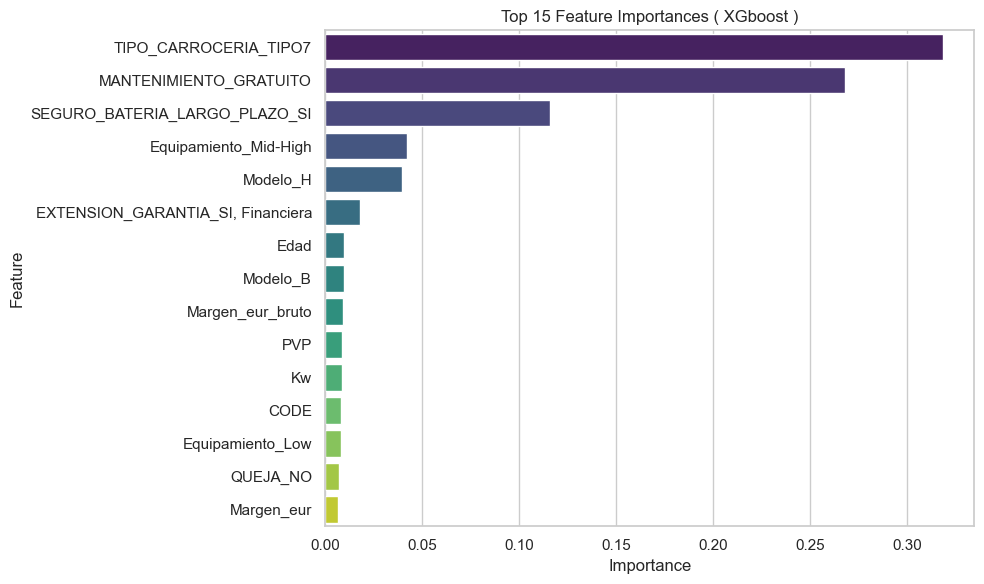

In [7]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score, ParameterSampler,RandomizedSearchCV
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, precision_recall_curve, roc_auc_score, auc, roc_curve
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from tqdm.auto import tqdm
from sklearn.preprocessing import OrdinalEncoder
import joblib
# 1. Preparar Datos
def preparar_datos(df):
    df = df.copy()
    print("Cuantos clientes hay antes de la limpieza ",df.shape[0])
    # Drop identifiers and dates
    # "CODE", "Customer_ID", "Id_Producto",, "FIN_GARANTIA","EN_GARANTIA","SEGURO_BATERIA_LARGO_PLAZO","km_ultima_revision","Km_medio_por_revision","Revisiones"         
    cols_to_drop_exact = [ "Sales_Date", "BASE_DATE",'TRANSMISION_ID',"Revisiones",'PROV_DESC',"km_ultima_revision","Km_medio_por_revision",'EN_GARANTIA','Id_Producto']# revisiones 0.25 "SEGURO_BATERIA_LARGO_PLAZO" 0.35 "km_ultima_revision" 0.14 Km_medio_por_revision 0.4
    df = df.drop(columns=[c for c in cols_to_drop_exact if c in df.columns], errors="ignore")
    # Handle NaNs according to rules
    if "QUEJA" in df.columns:
        df["QUEJA"] = df["QUEJA"].fillna("N")
    if "GENERO" in df.columns:
        df["GENERO"] = df["GENERO"].fillna("M")
        
    # Drop any remaining col with NaNs
    df = df.dropna(axis=1)
    print("Cuantos clientes hay despues de limpieza ",df.shape[0])
    # Extract Target
    if "Churn_400" in df.columns:
        y = df["Churn_400"].map({'Y':1,'N':0})
        X = df.drop(columns=["Churn_400"])
    else:
        y = None
        X = df
    
    # One-Hot Encoding
    # Encode high-cardinality features using sklearn's OrdinalEncoder\\n")
    high_card_cols = [col for col in X.select_dtypes(include=['object', 'category',]).columns if X[col].nunique() > 15]
    if high_card_cols:
        encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X[high_card_cols] = encoder.fit_transform(X[high_card_cols].astype(str))
        X['Customer_ID']= encoder.fit_transform(X[['Customer_ID']].astype(str))

    X = pd.get_dummies(X, drop_first=True)
    
    return X, y,encoder,high_card_cols

# 2. Evaluar Modelo
def evaluar_modelo(modelo, X_train, y_train, X_test, y_test):
    # Entrenar en Train
    modelo.fit(X_train, y_train)
    
    # Predict Test
    pred_test = modelo.predict(X_test)
    prob_test = modelo.predict_proba(X_test)[:, 1] if hasattr(modelo, "predict_proba") else pred_test
    
    f1_test = f1_score(y_test, pred_test)
    error_test = 1 - f1_test
    accuracy=accuracy_score(y_test,pred_test)
    precision_scalar = precision_score(y_test, pred_test,zero_division=0)
    recall_scalar = recall_score(y_test, pred_test,zero_division=0)
    precision, recall, _ = precision_recall_curve(y_test, prob_test)
    pr_auc_test = auc(recall, precision)
    roc_auc_test = roc_auc_score(y_test, prob_test)
    # print("precision :",precision_scalar)
    # print("recall :",recall_scalar)

    if precision_scalar==0 or recall_scalar==0:
        return -1.0, None
    
    # CV for diff error on train to see how generic it is to train data
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(modelo, X_train, y_train, cv=skf, scoring='f1', n_jobs=-1)
    error_cv = 1 - np.mean(cv_scores)
    diff_error = abs(error_test - error_cv)
    
    
    # Eval condition
    if (0.7 < f1_test <= 0.9 and pr_auc_test > 0.6 and roc_auc_test > 0.6 and diff_error < 0.20) or (recall_scalar>0.7 and precision_scalar>0.6 and diff_error < 0.20):# f1 change maybe to 0.6 or 0.7 precision min(>0.4)
        eval_results = {
            "f1": f1_test,
            "accuracy": accuracy_score(y_test, pred_test),
            "precision": precision_score(y_test, pred_test),
            "recall": recall_score(y_test, pred_test),
            "conf_matrix": confusion_matrix(y_test, pred_test),
            "pr_auc": pr_auc_test,
            "roc_auc": roc_auc_test,
            "diff_error": diff_error,
            "prob_test": prob_test, # Para graficar despues
            "precision_curve": precision,
            "recall_curve": recall,
            "SCORE":(0.50 * f1_test) - (0.30 * diff_error) + (0.10 * roc_auc_test) + (0.11 * pr_auc_test)
        }
        # Weights mapping as requested: F1 and diff_error are highly important.
        # Accuracy ROC AUC slightly more important than PR AUC
        # Example composite weighting representation mapping
        best_score = (0.55 * f1_test) - (0.30 * diff_error) + (0.05 * roc_auc_test) + (0.08 * pr_auc_test)
        return best_score, eval_results
    else:
        # eval_results = {
        #     "f1": f1_test,
        #     "accuracy": accuracy_score(y_test, pred_test),
        #     "precision": precision_score(y_test, pred_test),
        #     "recall": recall_score(y_test, pred_test),
        #     "conf_matrix": confusion_matrix(y_test, pred_test),
        #     "pr_auc": pr_auc_test,
        #     "roc_auc": roc_auc_test,
        #     "diff_error": diff_error,
        #     "prob_test": prob_test, # Para graficar despues
        #     "precision_curve": precision,
        #     "recall_curve": recall,
        #     "SCORE":(0.50 * f1_test) - (0.30 * diff_error) + (0.10 * roc_auc_test) + (0.08 * pr_auc_test)
        # }
        # 
        return -1.0, None #eval_results



def main():
    
    
    url = "https://storage.googleapis.com/jvelare-public/bq-results-20260211-093843-1770799837095"
    print("Descargando o cargando Dataset...")
    df_raw = pd.read_csv(url)
    
    print("Preparando Datos...")
    X, y,encoder,high_card_cols = preparar_datos(df_raw)
    
    # Ensure numerical structure logic
    X = X.astype(float)
    training_columns = X.columns.tolist()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print("Cuantos clientes,features en train",X_train.shape)
    # Parametros base
    pos = y_train.sum()          # since 1 = positive
    neg = len(y_train) - pos
    scale_pos_weight = neg / pos
    models = {
        "DecisionTree": (DecisionTreeClassifier(random_state=42), {
            'criterion': ['gini', 'entropy', 'log_loss'],
            'splitter': ['best', 'random'],
            'min_samples_leaf': [1, 2, 5, 6, 8],
            'min_samples_split': [2, 5, 10],
            'max_depth': [3, 5, 10],
             'class_weight':[None,'balanced']
        }), # 540 combinationes
        "RandomForest": (RandomForestClassifier(random_state=42, n_jobs=-1), {
             'criterion': ['gini', 'entropy', 'log_loss'],
             'min_samples_leaf': [1, 2, 5, 6, 8],
             'min_samples_split': [2, 5, 10],
             'max_depth': [3, 5, 10],
             'n_estimators': [100, 200],
             'class_weight':[None,'balanced']
        }), # 432 combinationes
        "XGBoost": (XGBClassifier(random_state=42, n_jobs=-1, eval_metric='aucpr'), {
             'max_depth': [3, 5, 10],
             'learning_rate': [0.01, 0.05, 0.1,0.25,0.005],
             'n_estimators': [100, 200],
             'gamma': [2, 5,7, 10],
              'scale_pos_weight': [scale_pos_weight*1.5,scale_pos_weight*0.5,scale_pos_weight],
              
        }) # 360 combinationes
    }
    
    # Keep a list of ALL valid models
    valid_models_found = []
    
    SEARCH_ITERATIONS = 360#270 #50 # Incrementado o decrementado segun el tiempo local (72 iter=79minutos)
    print(f"\nComenzando busqueda aleatoria de modelos con {SEARCH_ITERATIONS} iteraciones max por algoritmo.\n")
    
    # Tracking configurations already tested so we don't repeat them
    tested_params = []
    
    for name, (base_model, params) in models.items():
        print(f"\n\t--- {name} ---")
        
        param_list = list(ParameterSampler(params, n_iter=SEARCH_ITERATIONS, random_state=42))
        
        # Loop con TQDM
        with tqdm(total=len(param_list), desc=f"Evaluando {name}", leave=True) as pbar:
            for k, p in enumerate(param_list):
                # Check for duplicate params across algorithm runs
                param_signature = str(name) + str(p)
                if param_signature in tested_params:
                    pbar.update(1)
                    continue
                tested_params.append((name,p))
                
                # Clonar el modelo e inyectar params
                model_instance = base_model.__class__(**{**base_model.get_params(), **p})
                
                # Evaluar
                score, result_dict = evaluar_modelo(model_instance, X_train, y_train, X_test, y_test)
                
                if score != -1.0:
                    # Imprimir si nuestro modelo en este paso cumple todo.
                    tqdm.write(f"  [+] ¡Modelo validado! (Iter {k}) --> Params: {p}")
                    tqdm.write(f"      F1: {result_dict['f1']:.4f} | Diff Error: {result_dict['diff_error']:.4f} | SCORE: {result_dict['SCORE']:.4f} | ROC-AUC: {result_dict['roc_auc']:.4f} | PR-AUC: {result_dict['pr_auc']:.4f}")
                    
                    # Store valid models instead of just keeping the best overall immediately
                    valid_models_found.append({
                        "name": name,
                        "model": model_instance,
                        "params": p,
                        "score": score,
                        "results": result_dict
                    })
                
                pbar.update(1)
                
    # 4. Plots e Impresiones Finales
    if valid_models_found:
        # Sort best to worst according to the custom score calculation
        valid_models_found = sorted(valid_models_found, key=lambda x: x['score'], reverse=True)
        print("\n" + "="*50)
        print(f"✅ Encontramos {len(valid_models_found)} modelos calificados!")
        
        # Guardaremos esto en un txt, un dataframe u otra estructura (para este caso lo listamos)
        for idx, m in enumerate(valid_models_found):
             print(f" [{idx+1}] {m['name']} | Score: {m['score']:.4f} | Params: {m['params']}")
        
        best = valid_models_found[0]# Top 5 in order
        best_overall_name = best['name']
        best_overall_model = best['model']
        best_overall_results = best['results']
        # Save artifacts
        artifacts = {
            'model': best['model'],
            'encoder': encoder,
            'high_card_cols': high_card_cols,
            'training_columns': training_columns,
            'feature_names': training_columns,
            'metrics': best['results'],
            'name': best['name']
        }
        joblib.dump(artifacts, 'churn_model_artifacts.joblib')
        print(f"✅ Artefactos guardados en 'churn_model_artifacts.joblib'")
        print("\n" + "="*50)
        print(f"🥇 MEJOR MODELO GLOBAL: {best_overall_name} 🥇")
        print("="*50)
        print(f"⚙️ Parametros: {best_overall_model.get_params()}")
        print(f"📊 Metricas en TEST:")
        print(f"   F1 Score:  {best_overall_results['f1']:.4f}")
        print(f"   Accuracy:  {best_overall_results['accuracy']:.4f}")
        print(f"   Precision: {best_overall_results['precision']:.4f}")
        print(f"   Recall:    {best_overall_results['recall']:.4f}")
        print(f"   ROC AUC:   {best_overall_results['roc_auc']:.4f}")
        print(f"   PR AUC:    {best_overall_results['pr_auc']:.4f}")
        print(f"   Diff CV vs Test Error: {best_overall_results['diff_error']:.4f}")
        
        sns.set_theme(style="whitegrid")
        # for i in best:
        # A) Matriz de Confusion
        plt.figure(figsize=(6,4))
        sns.heatmap(best_overall_results['conf_matrix'], annot=True, fmt='d', cmap='Blues')
        plt.title(f"Matriz de Confusión - {best_overall_name}")
        plt.ylabel('Verdadero')
        plt.xlabel('Predicho')
        plt.show()

        # B) ROC Curve
        fpr, tpr, _ = roc_curve(y_test, best_overall_results['prob_test']) if 'prob_test' in best_overall_results else (None, None, None)
        if fpr is not None:
            plt.figure(figsize=(6,4))
            plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {best_overall_results["roc_auc"]:.2f})')
            plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('Tasa de Falsos Positivos')
            plt.ylabel('Tasa de Verdaderos Positivos')
            plt.title('Curva ROC')
            plt.legend(loc="lower right")
            plt.show()
            
        # C) PR Curve
        plt.figure(figsize=(6,4))
        plt.plot(best_overall_results['recall_curve'], best_overall_results['precision_curve'], color='green', lw=2, label=f'PR curve (area = {best_overall_results["pr_auc"]:.2f})')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Curva Precision-Recall')
        plt.legend(loc="lower left")
        plt.show()
        # l)
        if best_overall_name=="DecisionTree":
            plt.figure(figsize=(12, 8))

            plot_tree(best_overall_model,filled=True)
            plt.show()

        # D) Feature Importance
        if hasattr(best_overall_model, "feature_importances_"):
            importances = best_overall_model.feature_importances_
            feature_names = X.columns
            
            # Identify useless features (Importance == 0)
            useless_features = [feature_names[i] for i in range(len(importances)) if importances[i] == 0]
            if useless_features:
                 print(f"\\n🚫 Atributos sin importancia (Score = 0):")
                 print(useless_features[:10], "..." if len(useless_features)>10 else "")
            
            # Plot Top 15 Series
            importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
            importances_df = importances_df.sort_values(by='Importance', ascending=False).head(15)
            
            plt.figure(figsize=(10, 6))
            sns.barplot(x='Importance', y='Feature', data=importances_df, palette='viridis', hue='Feature', legend=False)
            plt.title(f"Top 15 Feature Importances ({best_overall_name})")
            plt.tight_layout()
            plt.show()
    else:
        print("\n❌ Ningun modelo analizado logro superar las condiciones de negocio requeridas.")
        One=XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss',**tested_params[-1][1])
        end=One.fit(X_train,y_train)
        importances = end.feature_importances_
        feature_names = X.columns
        
        # Identify useless features (Importance == 0)
        useless_features = [feature_names[i] for i in range(len(importances)) if importances[i] == 0]
        if useless_features:
                print(f"\n🚫 Atributos sin importancia (Score = 0):")
                print(useless_features[:10], "..." if len(useless_features)>10 else "")
        
        # Plot Top 15 Series
        importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        importances_df = importances_df.sort_values(by='Importance', ascending=False).head(15)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=importances_df, palette='viridis', hue='Feature', legend=False)
        plt.title(f"Top 15 Feature Importances ( XGboost )")
        plt.tight_layout()
        plt.show()
        # return best_overall_model
if __name__ == '__main__':
    main()


# Check with new Custumers with best model

In [ ]:
from xgboost import XGBClassifier


## Estrategia de Comercio